# Thesis

## 1. Data Exploration

### 1.1 Library Import

In [ ]:
# Install all necessary libraries
import sys
print(sys.executable)

# Data exploration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Cleaning
import string
import re
import nltk
import wordcloud
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize

# Model Preparation
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder


# Legacy Models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, SimpleRNN, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam  # Use TensorFlow's Keras optimizers


# BERT
from sklearn.model_selection import StratifiedKFold
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset

print(tf.__version__)
from tqdm import tqdm
from joblib import dump
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
from collections import deque

import transformers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


import warnings
warnings.filterwarnings("ignore")

/usr/bin/python3
2.13.0


/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


### 1.2. Data Import

In [ ]:
# Data Import
laptop = pd.read_csv('/content/Laptop_Train_v2.csv')
restaurants = pd.read_csv('/content/Restaurants_Train_v2.csv')

restaurants.head()



,id,Sentence,Aspect Term,polarity,from,to
0,3121,But the staff was so horrible to us.,staff,negative,8,13
1,2777,"To be completely fair, the only redeeming fact...",food,positive,57,61
2,1634,"The food is uniformly exceptional, with a very...",food,positive,4,8
3,1634,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62
4,1634,"The food is uniformly exceptional, with a very...",menu,neutral,141,145


In [ ]:
# Concatonate the two datasets

data = pd.concat([laptop, restaurants])
data.head()

,id,Sentence,Aspect Term,polarity,from,to
0,2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45
1,2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86
2,1316,The tech guy then said the service center does...,service center,negative,27,41
3,1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121
4,1316,The tech guy then said the service center does...,tech guy,neutral,4,12


### 1.3. Data Exploration

In [ ]:
# Inspecting the data
print(data.shape)


(6051, 6)


Let us now try and visualise the data for potential anomalies, null values and other such issues. We will also try to understand the distribution of the data.

In [ ]:
# Checking for missing values
data.isnull().sum()



,0
id,0
Sentence,0
Aspect Term,0
polarity,0
from,0
to,0


As we can see, there are no missing values in the data, let us now plot this in order to grasp its distribution.

Let us now understand how the target is distributed in the data.

polarity
positive    3151
negative    1671
neutral     1093
conflict     136
Name: count, dtype: int64


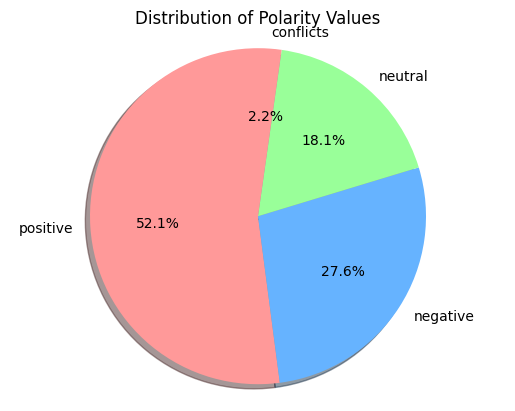

In [ ]:
# Distribution of target values
target_counts = data.polarity.value_counts()
print(target_counts)

# Create a figure with a single subplot
fig, ax = plt.subplots()

# Colors and explode settings for better visualization
colors = ['#ff9999','#66b3ff', '#99ff99']

# Pie chart for target values
ax.pie(target_counts, labels=['positive', 'negative', 'neutral','conflicts'], colors=colors, autopct='%1.1f%%', startangle=90, shadow=True)
ax.set_title('Distribution of Polarity Values')
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the plot
plt.show()

In [ ]:
# Drop "Conflict" Entries
data = data[data['polarity'] != 'conflict']

Now we will try to understand which kind of aspects are present in the data. All reviews are filtered by some specific identifying keyword, e.g. "computer" or "battery". Let us now try to understand the distribution of these aspects in the data.

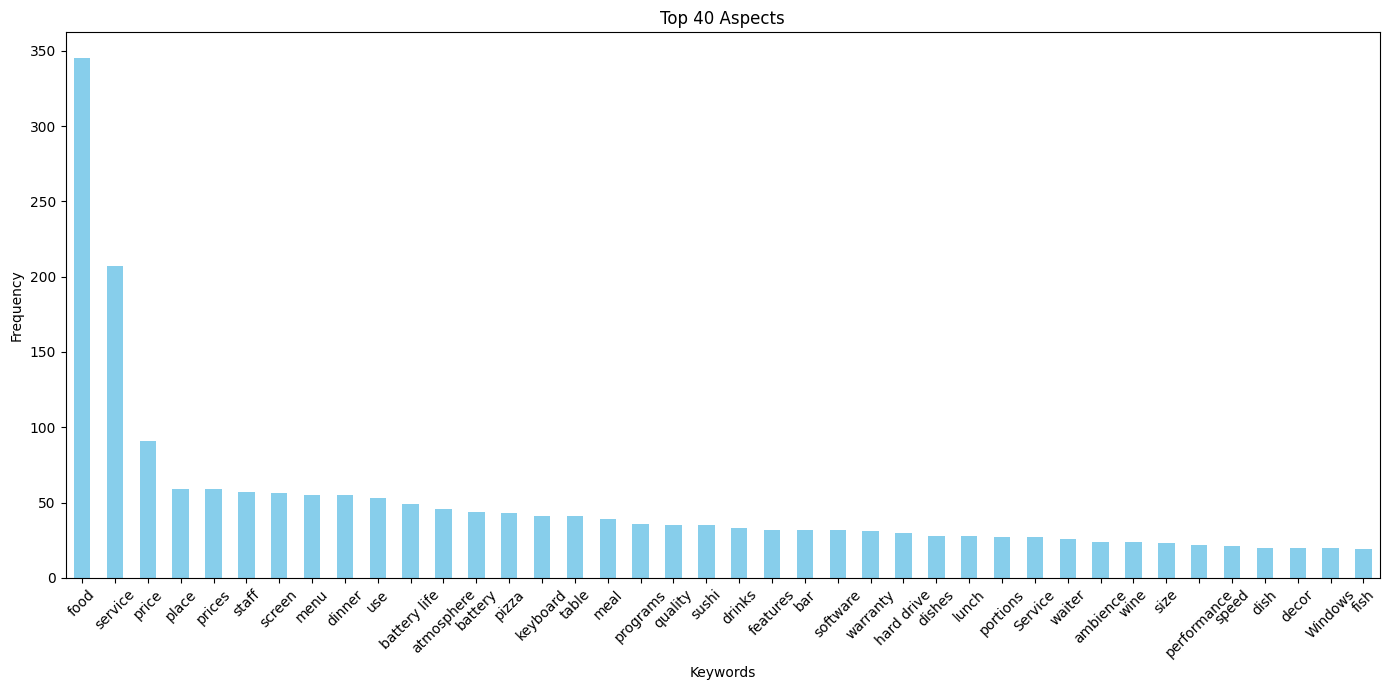

In [ ]:
# Create a bar plot of the top 20 keywords
data['Aspect Term'].value_counts().head(40).plot(kind='bar', figsize=(14, 7), color='skyblue')
plt.title('Top 40 Aspects')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Now let us move on to the text itself

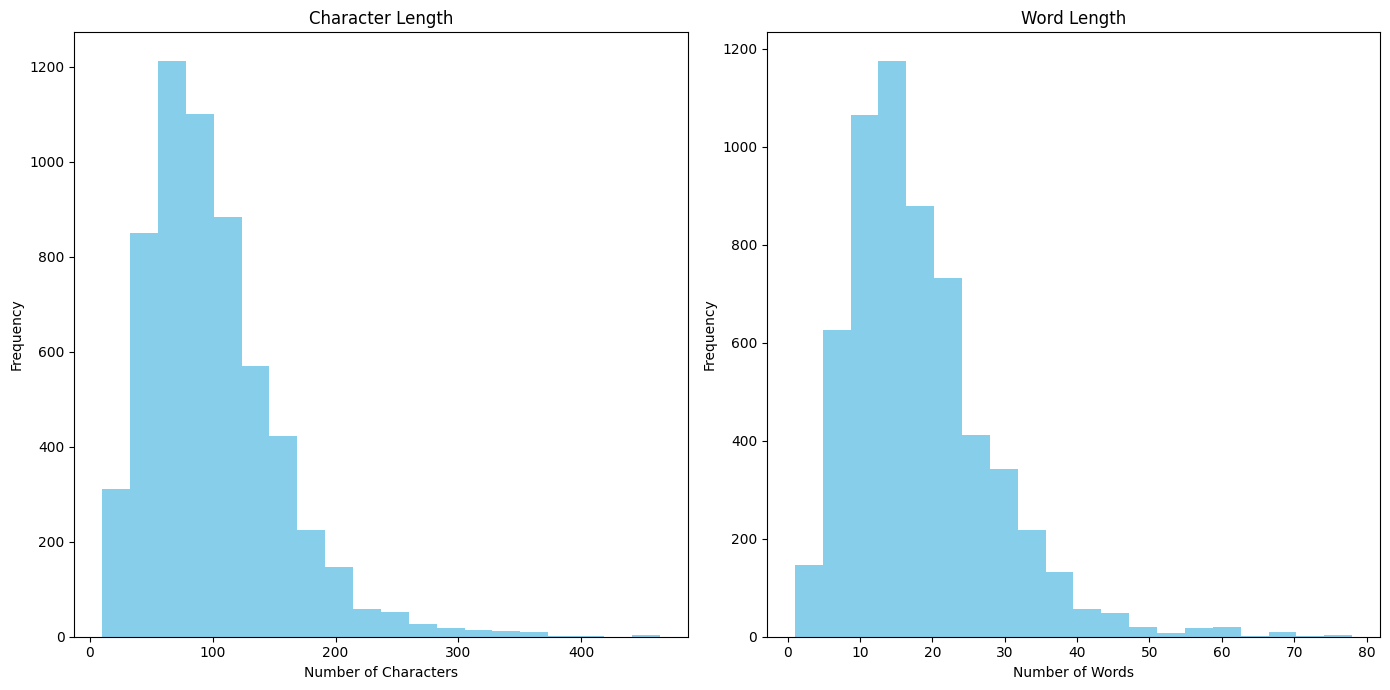

In [ ]:
# Make two bar plots of the character and the word length of the tweets
# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Character length plot
data['Sentence'].str.len().plot(kind='hist', bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Character Length')
ax[0].set_xlabel('Number of Characters')
ax[0].set_ylabel('Frequency')

# Word length plot
data['Sentence'].str.split().map(lambda x: len(x)).plot(kind='hist', bins=20, color='skyblue', ax=ax[1])
ax[1].set_title('Word Length')
ax[1].set_xlabel('Number of Words')
ax[1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

Now it is helpful to understand whether these numbers differ between the two classes.

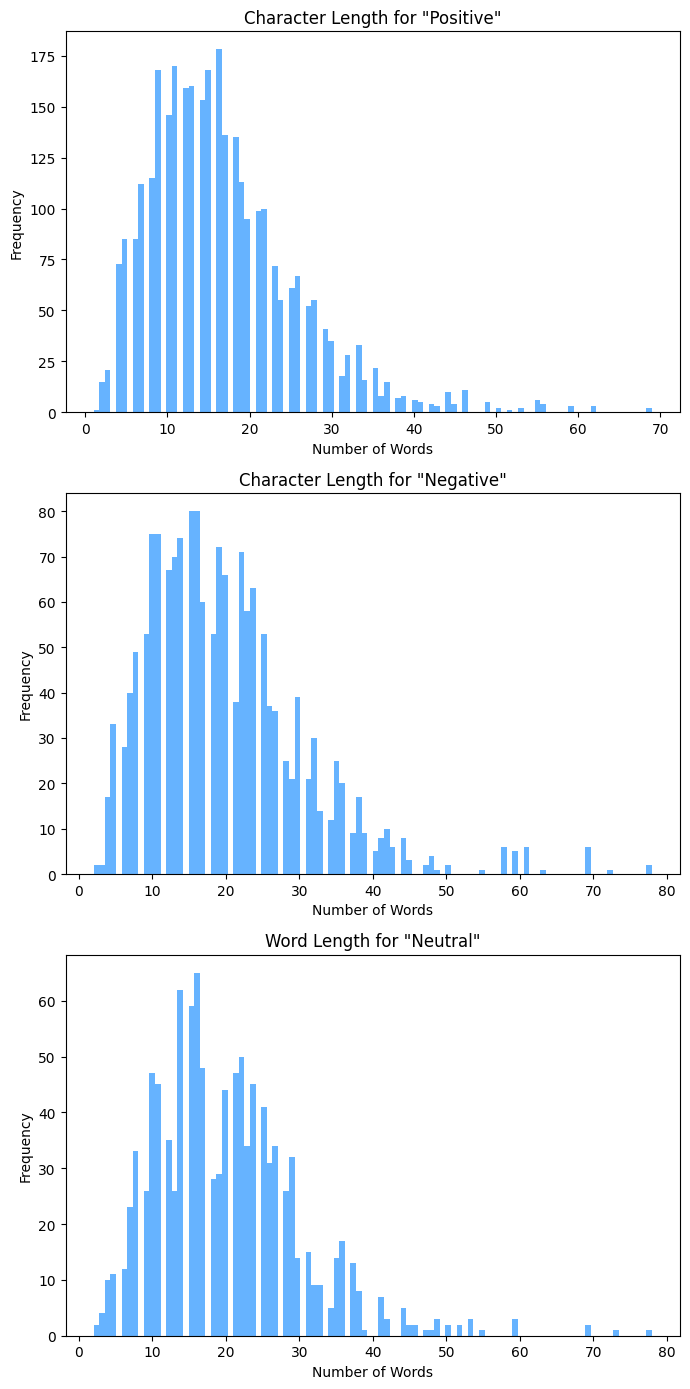

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(7, 14))

# Character length plot for disaster tweets
word_lengths_positive = data[data['polarity'] == "positive"]['Sentence'].str.split().map(len)
word_lengths_positive.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[0])
ax[0].set_title('Character Length for "Positive"')
ax[0].set_xlabel('Number of Words')
ax[0].set_ylabel('Frequency')

# Character length plot for non-disaster tweets
word_lengths_negative = data[data['polarity'] == 'negative']['Sentence'].str.split().map(len)
word_lengths_negative.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[1])
ax[1].set_title('Character Length for "Negative"')
ax[1].set_xlabel('Number of Words')
ax[1].set_ylabel('Frequency')

# Word length plot for disaster tweets
word_lengths_neutral = data[data['polarity'] == 'neutral']['Sentence'].str.split().map(len)
word_lengths_neutral.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[2])
ax[2].set_title('Word Length for "Neutral"')
ax[2].set_xlabel('Number of Words')
ax[2].set_ylabel('Frequency')


# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


We see that the distributions do not vary significantly between the classes. All are quite evenly distributed. The exception is "Conflict" Terms of which there are not many in the data.

### 1.4 Data Cleaning

In [ ]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuations and numbers
    text = re.sub(r'[^\w\s]', '', text)
    # Remove leading and trailing whitespaces
    text = text.strip()
    return text

# Apply the cleaning function to the text column
data['Sentence'] = data['Sentence'].apply(clean_text)

In [ ]:
data.head(10)

,id,Sentence,Aspect Term,polarity,from,to
0,2339,i charge it at night and skip taking the cord ...,cord,neutral,41,45
1,2339,i charge it at night and skip taking the cord ...,battery life,positive,74,86
2,1316,the tech guy then said the service center does...,service center,negative,27,41
3,1316,the tech guy then said the service center does...,"""sales"" team",negative,109,121
4,1316,the tech guy then said the service center does...,tech guy,neutral,4,12
5,2005,it is of high quality has a killer gui is extr...,quality,positive,14,21
6,2005,it is of high quality has a killer gui is extr...,GUI,positive,36,39
7,2005,it is of high quality has a killer gui is extr...,applications,positive,118,130
8,2005,it is of high quality has a killer gui is extr...,use,positive,143,146
9,2789,easy to start up and does not overheat as much...,start up,positive,8,16


Let us now tokenize the data.

In [ ]:
# Value counts for polarity
data['polarity'].value_counts()

,count
polarity,
positive,3151
negative,1671
neutral,1093


## 2. Model Selection and Training

We will initially run sentiment analysis using all legacy models discussed in the thesis on the pure sentences (not including the aspect term). This however only works if there is only one aspect per sentence. So let us first filter out all sentences that contain more than one aspect.

### Preprocessing

In [ ]:
data.head()

,id,Sentence,Aspect Term,polarity,from,to
0,2339,i charge it at night and skip taking the cord ...,cord,neutral,41,45
1,2339,i charge it at night and skip taking the cord ...,battery life,positive,74,86
2,1316,the tech guy then said the service center does...,service center,negative,27,41
3,1316,the tech guy then said the service center does...,"""sales"" team",negative,109,121
4,1316,the tech guy then said the service center does...,tech guy,neutral,4,12


In [ ]:
data[['Aspect Term', 'polarity', 'from', 'to']] = data[['Aspect Term', 'polarity', 'from', 'to']].astype(str)

# Group by 'id', concatenate the desired columns, and keep the first occurrence of 'category'
model_data = data.groupby('id', sort=False).agg({
    'Sentence': 'first',
    'Aspect Term': ', '.join,     # Concatenate 'Aspect Term'
    'polarity': ', '.join,        # Concatenate 'polarity'
    'from': ', '.join,            # Concatenate 'from'
    'to': ', '.join,              # Concatenate 'to'          # Keep the first occurrence of 'category'
}).reset_index()

model_data.head()

,id,Sentence,Aspect Term,polarity,from,to
0,2339,i charge it at night and skip taking the cord ...,"cord, battery life","neutral, positive","41, 74","45, 86"
1,1316,the tech guy then said the service center does...,"service center, ""sales"" team, tech guy, food","negative, negative, neutral, neutral","27, 109, 4, 4","41, 121, 12, 8"
2,2005,it is of high quality has a killer gui is extr...,"quality, GUI, applications, use","positive, positive, positive, positive","14, 36, 118, 143","21, 39, 130, 146"
3,2789,easy to start up and does not overheat as much...,start up,positive,8,16
4,76,i even got my teenage son one because of the f...,"features, iChat, Photobooth, garage band","positive, positive, positive, positive","46, 77, 84, 96","54, 82, 94, 107"


In [ ]:

# Split the 'Aspect Term', 'from', and 'to' columns into lists
model_data['Aspect Term'] = model_data['Aspect Term'].apply(lambda x: x.split(','))
model_data['polarity'] = model_data['polarity'].apply(lambda x: x.split(','))
model_data['from'] = model_data['from'].apply(lambda x: list(map(int, x.split(','))))  # Convert to list of integers
model_data['to'] = model_data['to'].apply(lambda x: list(map(int, x.split(','))))  # Convert to list of integers

# Now each row has 'Aspect Term', 'from', and 'to' as lists
model_data[['Sentence', 'Aspect Term','polarity', 'from', 'to']].head()



,Sentence,Aspect Term,polarity,from,to
0,i charge it at night and skip taking the cord ...,"[cord, battery life]","[neutral, positive]","[41, 74]","[45, 86]"
1,the tech guy then said the service center does...,"[service center, ""sales"" team, tech guy, food]","[negative, negative, neutral, neutral]","[27, 109, 4, 4]","[41, 121, 12, 8]"
2,it is of high quality has a killer gui is extr...,"[quality, GUI, applications, use]","[positive, positive, positive, positive]","[14, 36, 118, 143]","[21, 39, 130, 146]"
3,easy to start up and does not overheat as much...,[start up],[positive],[8],[16]
4,i even got my teenage son one because of the f...,"[features, iChat, Photobooth, garage band]","[positive, positive, positive, positive]","[46, 77, 84, 96]","[54, 82, 94, 107]"


In [ ]:
from nltk.tokenize import word_tokenize
nltk.download('punkt')

# Function to label tokens in a sentence based on multiple aspect terms
def label_tokens_multi_aspect(row):
    sentence = row['Sentence']
    aspect_terms = row['Aspect Term']  # List of aspect terms
    from_indices = row['from']  # List of starting character indices
    to_indices = row['to']  # List of ending character indices

    # Tokenize the sentence
    tokens = word_tokenize(sentence)
    labels = ['O'] * len(tokens)  # Initialize all labels to 'O'

    # Loop through each aspect term and its corresponding character indices
    for aspect, from_idx, to_idx in zip(aspect_terms, from_indices, to_indices):
        current_pos = 0
        start_token_idx = None
        end_token_idx = None

        # Find the start and end indices of tokens corresponding to the aspect term
        for idx, token in enumerate(tokens):
            start_pos = current_pos
            end_pos = start_pos + len(token)  # End position of the token

            if start_pos <= from_idx < end_pos:
                start_token_idx = idx  # Aspect starts here
            if start_pos < to_idx <= end_pos:
                end_token_idx = idx  # Aspect ends here
                break

            current_pos += len(token) + 1  # Move to the next token (account for spaces)

        # Label the tokens for this aspect
        if start_token_idx is not None and end_token_idx is not None:
            labels[start_token_idx] = 'B-aspect'
            for i in range(start_token_idx + 1, end_token_idx + 1):
                labels[i] = 'I-aspect'

    return tokens, labels

# Apply the function to each row in the DataFrame
model_data['tokenized_sentences'], model_data['token_labels'] = zip(*model_data.apply(label_tokens_multi_aspect, axis=1))

# Check the result
print(model_data[['Sentence', 'tokenized_sentences', 'token_labels']].head())



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                            Sentence  \
0  i charge it at night and skip taking the cord ...   
1  the tech guy then said the service center does...   
2  it is of high quality has a killer gui is extr...   
3  easy to start up and does not overheat as much...   
4  i even got my teenage son one because of the f...   

                                 tokenized_sentences  \
0  [i, charge, it, at, night, and, skip, taking, ...   
1  [the, tech, guy, then, said, the, service, cen...   
2  [it, is, of, high, quality, has, a, killer, gu...   
3  [easy, to, start, up, and, does, not, overheat...   
4  [i, even, got, my, teenage, son, one, because,...   

                                        token_labels  
0  [O, O, O, O, O, O, O, O, O, B-aspect, O, O, O,...  
1  [O, B-aspect, I-aspect, O, O, O, B-aspect, I-a...  
2  [O, O, O, O, B-aspect, O, O, O, O, O, O, O, O,...  
3  [O, O, B-aspect, I-aspect, O, O, O, O, O, O, O...  
4  [O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..

Shape of X: (2651, 50)
Shape of y: (2651, 50)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 128)           631296    
                                                                 
 simple_rnn (SimpleRNN)      (None, 50, 64)            12352     
                                                                 
 time_distributed (TimeDist  (None, 50, 3)             195       
 ributed)                                                        
                                                                 
Total params: 643843 (2.46 MB)
Trainable params: 643843 (2.46 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
75/75 [==============================] - 3s 21ms/step - loss: 0.3120 - accuracy: 0.9127 - sequence_accuracy: 0.1381 - val_loss: 0.1866 - val_accuracy: 0.9574 - v

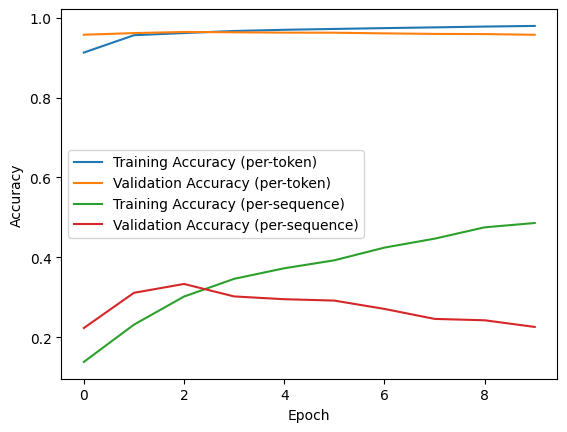

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, TimeDistributed, Dense, Dropout
from sklearn.model_selection import train_test_split

max_len = 50  # Or any other max length suitable for your dataset
label2idx = {'O': 0, 'B-aspect': 1, 'I-aspect': 2}
num_classes = len(label2idx)
# Tokenizer for converting tokens to indices
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(model_data['tokenized_sentences'])  # Fit on the tokenized sentences
word_index = tokenizer.word_index  # Mapping of words to indices

# Convert tokenized sentences to sequences of indices (X)
X = tokenizer.texts_to_sequences(model_data['tokenized_sentences'])

# Pad sequences to the same length (max_len)
X = pad_sequences(X, maxlen=max_len, padding='post')

# Convert token labels to indices (y)
y = [[label2idx[label] for label in label_seq] for label_seq in model_data['token_labels']]

# Pad label sequences to match the token sequences (max_len)
y = pad_sequences(y, maxlen=max_len, padding='post', value=label2idx['O'])

# Convert y to a numpy array
y = np.array(y)

# Check the shape of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Split the data into training and validation sets (e.g., 90% training, 10% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


# Define model architecture
vocab_size = len(word_index) + 1  # Add 1 for padding/unknown tokens
embedding_dim = 128  # Dimension of the word embeddings
hidden_units = 64  # Number of LSTM hidden units

model = Sequential()
# Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
# Simple LSTM layer
model.add(SimpleRNN(units=hidden_units, return_sequences=True, recurrent_dropout=0.2))
# TimeDistributed layer to output label predictions for each token
model.add(TimeDistributed(Dense(num_classes, activation='softmax')))

def sequence_accuracy(y_true, y_pred):
    # y_pred: shape (batch_size, sequence_length, num_classes)
    # y_true: shape (batch_size, sequence_length)

    # Convert predictions to the predicted class index
    y_pred_idx = tf.argmax(y_pred, axis=-1)  # shape: (batch_size, sequence_length)

    # Ensure y_true is of the correct shape (batch_size, sequence_length)
    y_true = tf.cast(y_true, tf.int64)  # Convert to int64 to match y_pred_idx dtype

    # Compare the predicted indices with the true labels
    is_equal = tf.reduce_all(tf.equal(y_true, y_pred_idx), axis=-1)  # shape: (batch_size)

    # Return the mean accuracy over all sequences in the batch
    return tf.reduce_mean(tf.cast(is_equal, tf.float32))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy', sequence_accuracy])


# Model summary to review the architecture
model.summary()

# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val))

# Evaluate the model on the validation set
loss, accuracy, sequence_acc = model.evaluate(X_val, y_val)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy (per-token): {accuracy}")
print(f"Validation Accuracy (per-sequence): {sequence_acc}")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy (per-token)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (per-token)')
plt.plot(history.history['sequence_accuracy'], label='Training Accuracy (per-sequence)')
plt.plot(history.history['val_sequence_accuracy'], label='Validation Accuracy (per-sequence)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### LSTM

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 50, 128)           631296    
                                                                 
 lstm (LSTM)                 (None, 50, 64)            49408     
                                                                 
 time_distributed_1 (TimeDi  (None, 50, 3)             195       
 stributed)                                                      
                                                                 
Total params: 680899 (2.60 MB)
Trainable params: 680899 (2.60 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
75/75 [==============================] - 5s 36ms/step - loss: 0.3263 - accuracy: 0.9403 - sequence_accuracy: 0.1449 - val_loss: 0.1813 - val_accuracy: 0.9551 - val_sequence_accuracy: 0.1674
Epoch 2/10
75/7

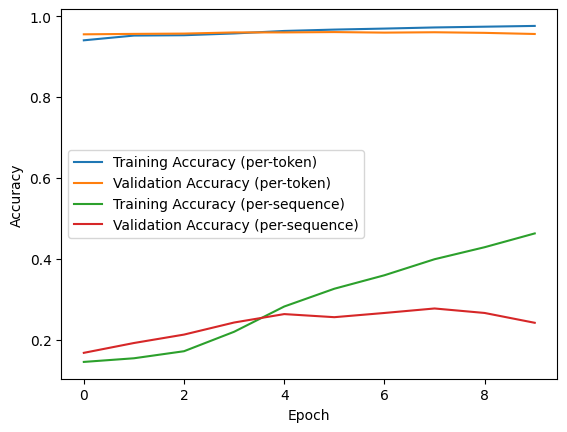

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN,LSTM, TimeDistributed, Dense, Dropout
from sklearn.model_selection import train_test_split


# Split the data into training and validation sets (e.g., 90% training, 10% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


# Define model architecture
vocab_size = len(word_index) + 1  # Add 1 for padding/unknown tokens
embedding_dim = 128  # Dimension of the word embeddings
hidden_units = 64  # Number of LSTM hidden units

model = Sequential()
# Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
# Simple LSTM layer
model.add(LSTM(units=hidden_units, return_sequences=True, recurrent_dropout=0.2))
# TimeDistributed layer to output label predictions for each token
model.add(TimeDistributed(Dense(num_classes, activation='softmax')))

def sequence_accuracy(y_true, y_pred):
    # y_pred: shape (batch_size, sequence_length, num_classes)
    # y_true: shape (batch_size, sequence_length)

    # Convert predictions to the predicted class index
    y_pred_idx = tf.argmax(y_pred, axis=-1)  # shape: (batch_size, sequence_length)

    # Ensure y_true is of the correct shape (batch_size, sequence_length)
    y_true = tf.cast(y_true, tf.int64)  # Convert to int64 to match y_pred_idx dtype

    # Compare the predicted indices with the true labels
    is_equal = tf.reduce_all(tf.equal(y_true, y_pred_idx), axis=-1)  # shape: (batch_size)

    # Return the mean accuracy over all sequences in the batch
    return tf.reduce_mean(tf.cast(is_equal, tf.float32))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy', sequence_accuracy])


# Model summary to review the architecture
model.summary()

# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val))

# Evaluate the model on the validation set
loss, accuracy, sequence_acc = model.evaluate(X_val, y_val)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy (per-token): {accuracy}")
print(f"Validation Accuracy (per-sequence): {sequence_acc}")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy (per-token)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (per-token)')
plt.plot(history.history['sequence_accuracy'], label='Training Accuracy (per-sequence)')
plt.plot(history.history['val_sequence_accuracy'], label='Validation Accuracy (per-sequence)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### Bidirectional LSTM

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 50, 128)           631296    
                                                                 
 bidirectional (Bidirection  (None, 50, 128)           98816     
 al)                                                             
                                                                 
 time_distributed_2 (TimeDi  (None, 50, 3)             387       
 stributed)                                                      
                                                                 
Total params: 730499 (2.79 MB)
Trainable params: 730499 (2.79 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
75/75 [==============================] - 9s 60ms/step - loss: 0.2926 - accuracy: 0.9399 - sequence_accuracy: 0.1469 - val_loss: 0.1572 - va

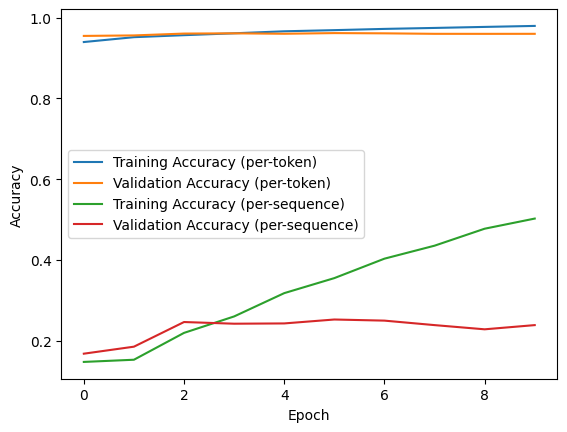

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN,LSTM, TimeDistributed, Dense, Dropout, Bidirectional
from sklearn.model_selection import train_test_split


# Split the data into training and validation sets (e.g., 90% training, 10% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


# Define model architecture
vocab_size = len(word_index) + 1  # Add 1 for padding/unknown tokens
embedding_dim = 128  # Dimension of the word embeddings
hidden_units = 64  # Number of LSTM hidden units

model = Sequential()
# Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
# Bidirectional LSTM layer
model.add(Bidirectional(LSTM(units=hidden_units, return_sequences=True, recurrent_dropout=0.2)))
# TimeDistributed layer to output label predictions for each token
model.add(TimeDistributed(Dense(num_classes, activation='softmax')))

def sequence_accuracy(y_true, y_pred):
    # y_pred: shape (batch_size, sequence_length, num_classes)
    # y_true: shape (batch_size, sequence_length)

    # Convert predictions to the predicted class index
    y_pred_idx = tf.argmax(y_pred, axis=-1)  # shape: (batch_size, sequence_length)

    # Ensure y_true is of the correct shape (batch_size, sequence_length)
    y_true = tf.cast(y_true, tf.int64)  # Convert to int64 to match y_pred_idx dtype

    # Compare the predicted indices with the true labels
    is_equal = tf.reduce_all(tf.equal(y_true, y_pred_idx), axis=-1)  # shape: (batch_size)

    # Return the mean accuracy over all sequences in the batch
    return tf.reduce_mean(tf.cast(is_equal, tf.float32))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy', sequence_accuracy])


# Model summary to review the architecture
model.summary()

# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val))

# Evaluate the model on the validation set
loss, accuracy, sequence_acc = model.evaluate(X_val, y_val)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy (per-token): {accuracy}")
print(f"Validation Accuracy (per-sequence): {sequence_acc}")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy (per-token)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (per-token)')
plt.plot(history.history['sequence_accuracy'], label='Training Accuracy (per-sequence)')
plt.plot(history.history['val_sequence_accuracy'], label='Validation Accuracy (per-sequence)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### BERT for Aspect Identification

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForTokenClassification.

Some weights or buffers of the TF 2.0 model TFBertForTokenClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_token_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  108891648 
                                                                 
 dropout_37 (Dropout)        multiple                  0         
                                                                 
 classifier (Dense)          multiple                  2307      
                                                                 
Total params: 108893955 (415.40 MB)
Trainable params: 108893955 (415.40 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/5
265/265 [==============================] - 230s 756ms/step - loss: 0.1478 - accuracy: 0.9528 - sequence_accuracy: 0.2047 - val_loss: 0.1101 - val_accuracy: 0.9610 - val_sequence_accuracy: 0.2531
Epoch 2/5
265/265 [============================

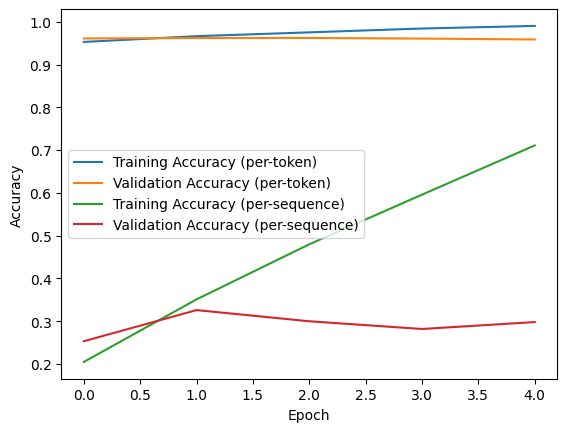

In [ ]:
from transformers import BertTokenizer, TFBertForTokenClassification
import tensorflow as tf
from tensorflow.keras.optimizers import Adam


# Load the tokenizer and the model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
num_labels = 3  # 'O', 'B-aspect', 'I-aspect'
model = TFBertForTokenClassification.from_pretrained('bert-base-uncased', num_labels=num_labels, classifier_dropout=0.5)

# Print model summary
model.summary()

# Tokenize the input data
def tokenize_and_align_labels(sentences, labels, max_len, tokenizer, label2idx):
    input_ids = []
    attention_masks = []
    label_ids = []

    for sentence, label in zip(sentences, labels):
        tokenized_input = tokenizer(
            sentence,
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors="tf",
            is_split_into_words=True  # Input sentence already tokenized
        )

        input_ids.append(tokenized_input['input_ids'].numpy().squeeze(0))
        attention_masks.append(tokenized_input['attention_mask'].numpy().squeeze(0))

        # Align labels to tokenized input
        aligned_labels = []
        for i, word in enumerate(sentence):
            word_pieces = tokenizer.tokenize(word)
            aligned_labels.append(label2idx[label[i]])  # Assign label to the first subword
            aligned_labels.extend([label2idx['O']] * (len(word_pieces) - 1))  # 'O' for subword tokens

        aligned_labels = aligned_labels[:max_len] + [label2idx['O']] * (max_len - len(aligned_labels))
        label_ids.append(aligned_labels)

    return tf.convert_to_tensor(input_ids), tf.convert_to_tensor(attention_masks), tf.convert_to_tensor(label_ids)

# Define label-to-index mapping
label2idx = {'O': 0, 'B-aspect': 1, 'I-aspect': 2}

# Example: Tokenizing sentences and labels
max_len = 50
input_ids, attention_masks, label_ids = tokenize_and_align_labels(
    model_data['tokenized_sentences'],  # List of tokenized sentences
    model_data['token_labels'],         # Corresponding list of labels
    max_len=max_len,
    tokenizer=tokenizer,
    label2idx=label2idx
)

# Split data into training and validation sets
from sklearn.model_selection import train_test_split
# Convert TensorFlow tensors to NumPy arrays for train_test_split
input_ids_np = input_ids.numpy()
attention_masks_np = attention_masks.numpy()
label_ids_np = label_ids.numpy()

# Split data into training and validation sets using train_test_split
train_ids, val_ids, train_masks, val_masks, train_labels, val_labels = train_test_split(
    input_ids_np, attention_masks_np, label_ids_np, test_size=0.2, random_state=42
)

# Convert the NumPy arrays back to TensorFlow tensors for model training
train_ids = tf.convert_to_tensor(train_ids)
val_ids = tf.convert_to_tensor(val_ids)
train_masks = tf.convert_to_tensor(train_masks)
val_masks = tf.convert_to_tensor(val_masks)
train_labels = tf.convert_to_tensor(train_labels)
val_labels = tf.convert_to_tensor(val_labels)


# Build TensorFlow datasets
batch_size = 8

train_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': train_ids, 'attention_mask': train_masks}, train_labels))
train_dataset = train_dataset.shuffle(len(train_ids)).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': val_ids, 'attention_mask': val_masks}, val_labels))
val_dataset = val_dataset.batch(batch_size)

def sequence_accuracy(y_true, y_pred):
    # Convert predictions and true labels from one-hot encoding to label indices
    y_pred_idx = tf.argmax(y_pred, axis=-1)
    y_true_idx = tf.cast(y_true, dtype=tf.int64)

    # Check if all tokens in a sequence match
    is_equal = tf.reduce_all(tf.equal(y_true_idx, y_pred_idx), axis=-1)

    # Return the mean of sequences where all tokens are correctly predicted
    return tf.reduce_mean(tf.cast(is_equal, tf.float32))


# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)  # Ensure it's from tensorflow.keras.optimizers
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy', sequence_accuracy])

# Train the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=5)

val_loss, val_accuracy, val_sequence_accuracy = model.evaluate(val_dataset)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy (per-token): {val_accuracy:.4f}")
print(f"Validation Accuracy (per-sequence): {val_sequence_accuracy:.4f}")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy (per-token)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (per-token)')
plt.plot(history.history['sequence_accuracy'], label='Training Accuracy (per-sequence)')
plt.plot(history.history['val_sequence_accuracy'], label='Validation Accuracy (per-sequence)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


